# Bitcoin Price Prediction using TimesFM 3.0

This notebook demonstrates how to use Google's TimesFM 3.0 zero-shot forecasting model to predict future Bitcoin (BTC-USD) prices.

1. **Data Collection**: Fetch the last 2 years of daily Bitcoin closing prices using `yfinance`.
2. **TimesFM 3.0 Initialization**: Load the pretrained model from Hugging Face.
3. **Zero-Shot Forecasting**: Predict the next 30 days without any model fine-tuning.
4. **Visualization**: Plot the historical prices and the forecasted trajectory with uncertainty intervals (quantiles).

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from timesfm3 import TimesFM3Forecaster

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

/home/dskim/fork/timesfm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fetch Bitcoin Historical Data
We'll use `yfinance` to download the historical daily data for BTC-USD.

In [2]:
ticker = "BTC-USD"
data = yf.download(ticker, period="2y", interval="1d")

if isinstance(data.columns, pd.MultiIndex):
    close_prices = data['Close'][ticker].values
    dates = data.index
else:
    close_prices = data['Close'].values
    dates = data.index

# We want the last 150 days total for this evaluation
# 120 days for context, 30 days for ground truth
eval_len = 150
horizon_len = 30
context_len = eval_len - horizon_len

recent_prices = close_prices[-eval_len:].astype(np.float32)
recent_dates = dates[-eval_len:]

# Split into context and ground truth
context = recent_prices[:context_len]
ground_truth = recent_prices[context_len:]
context_dates = recent_dates[:context_len]
gt_dates = recent_dates[context_len:]

print(f"Context length: {len(context)} days")
print(f"Ground truth length: {len(ground_truth)} days")

[*********************100%***********************]  1 of 1 completed

Fetched 731 days of BTC-USD historical data.


## 2. Load TimesFM 3.0 Model
Loading the PyTorch weights from the Hugging Face hub. We explicitly set `device="cpu"` to ensure compatibility across different GPU architectures.

In [3]:
forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    per_core_batch_size=4,
    device="cpu"  # Using CPU for broad compatibility
)
print(f"TimesFM3 loaded on device: {forecaster.device}")

TimesFM3 loaded on device: cpu


## 3. Predict Future Prices (30 Days)
Now we feed the historical data (context) into the model and ask it to predict the next 30 days.

In [4]:
# Run zero-shot forecast on the context to predict the next 30 days
torch_out = forecaster.predict(
    context=context,
    horizon=horizon_len,
    return_quantiles=True,
)

print("Forecast generated successfully!")
print(f"Point forecast shape: {torch_out.forecast.shape}")

# Calculate Error (MAE)
mae = np.mean(np.abs(torch_out.forecast - ground_truth))
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Forecast generated successfully!
Point forecast shape: (30,)


## 4. Visualize the Forecast
Plot the historical closing prices and the model's future forecast alongside the uncertainty intervals.

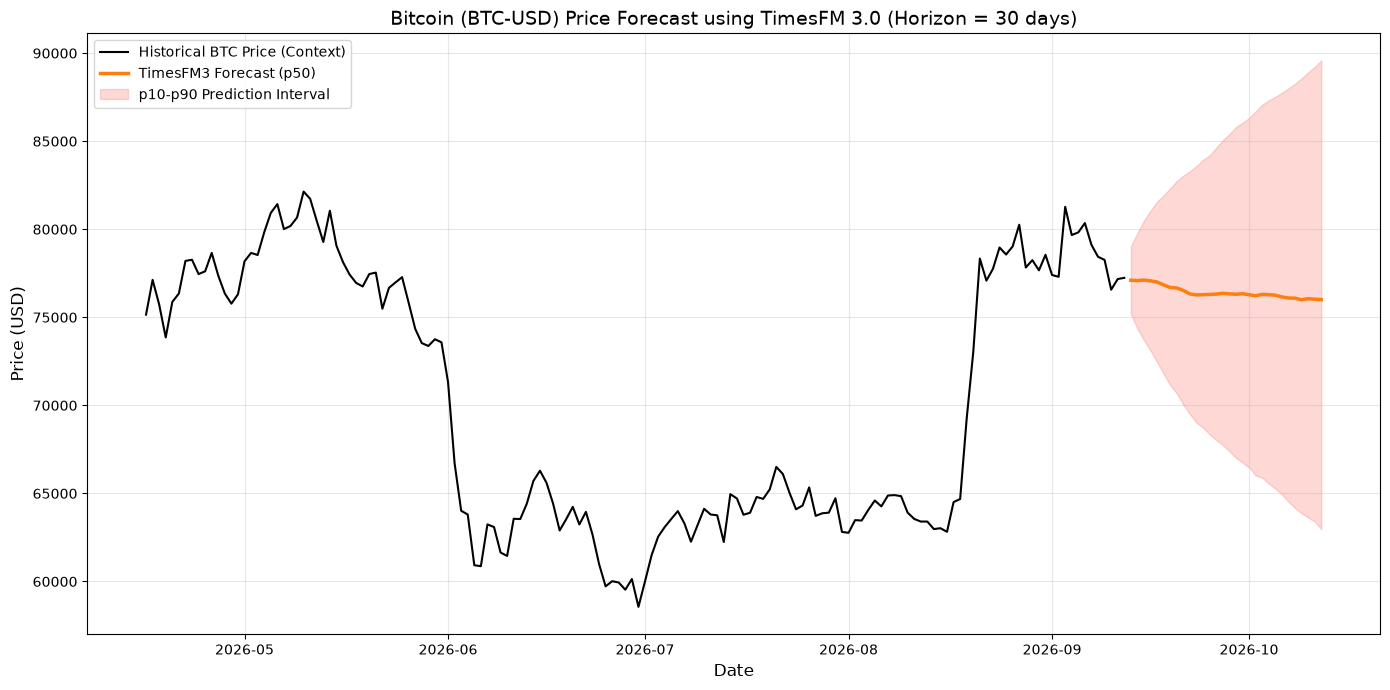

In [5]:
plt.figure(figsize=(14, 7))

# Plot the 120 days of context
plt.plot(context_dates, context, label="Context (Input)", color="black", linewidth=1.5)

# Plot the 30 days of actual ground truth
plt.plot(gt_dates, ground_truth, label="Actual BTC Price (Ground Truth)", color="gray", linestyle="--", linewidth=2.0)

# Plot the forecast median (point forecast)
plt.plot(gt_dates, torch_out.forecast, label="TimesFM3 Forecast (p50)", color="#ff7f0e", linewidth=2.5)

# Plot uncertainty intervals
if torch_out.quantiles is not None:
    plt.fill_between(
        gt_dates,
        torch_out.quantiles[:, 0],   # usually p10
        torch_out.quantiles[:, -1],  # usually p90
        color="salmon",
        alpha=0.3,
        label="p10-p90 Prediction Interval",
    )

plt.title(f"Bitcoin Price Forecast Evaluation (Horizon = {horizon_len} days, Context = {context_len} days)", fontsize=14)
plt.ylabel("Price (USD)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()